In [3]:
import os
import re
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:
DATA_PATH = "../dataset/go_emotions_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (211225, 31)


,id,text,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eew5j0j,That game hurt.,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,eemcysk,>sexuality shouldn’t be a grouping category I...,True,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ed2mah1,"You do right, if you don't care then fuck 'em!",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,eeibobj,Man I love reddit.,False,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,eda6yn6,"[NAME] was nowhere near them, he was by the Fa...",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [7]:
print(df.columns)

Index(['id', 'text', 'example_very_unclear', 'admiration', 'amusement',
       'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity',
       'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment',
       'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
       'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse',
       'sadness', 'surprise', 'neutral'],
      dtype='object')


In [9]:
if "label" not in df.columns:
    emotion_columns = [col for col in df.columns if col not in {"id", "text", "example_very_unclear"}]
    if not emotion_columns:
        raise ValueError("No emotion indicator columns found to derive label from.")

    def get_label(row):
        labels = row[emotion_columns][row[emotion_columns] == 1].index.tolist()
        return labels[0] if labels else "none"

    df["label"] = df.apply(get_label, axis=1)
    print("Derived label column from emotion indicator columns.")
else:
    print("Label column already exists.")

required_columns = {"text", "label"}
missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}. Please rename your columns to text and label.")

print("Required columns found.")

Derived label column from emotion indicator columns.
Required columns found.


In [10]:
print("Unique labels:")
print(df["label"].unique())

print("\nLabel counts:")
print(df["label"].value_counts())

Unique labels:
['sadness' 'none' 'neutral' 'love' 'gratitude' 'disapproval' 'amusement'
 'disappointment' 'admiration' 'realization' 'annoyance' 'confusion'
 'optimism' 'curiosity' 'excitement' 'caring' 'disgust' 'remorse' 'joy'
 'approval' 'embarrassment' 'surprise' 'anger' 'grief' 'pride' 'desire'
 'relief' 'fear' 'nervousness']

Label counts:
label
neutral           55298
admiration        17131
approval          15530
annoyance         11929
disapproval        8917
amusement          8862
gratitude          8437
anger              7956
curiosity          7707
disappointment     6769
confusion          6600
love               5310
caring             5147
realization        5125
joy                5120
optimism           4994
excitement         4375
sadness            3863
surprise           3472
disgust            3420
none               3411
desire             3002
fear               2514
embarrassment      1720
remorse            1648
nervousness         946
relief              81

In [11]:
main_emotions = ["joy", "sadness", "anger", "fear", "love", "surprise"]

df = df[df["label"].isin(main_emotions)].copy()

print("Filtered dataset shape:", df.shape)
print(df["label"].value_counts())

Filtered dataset shape: (28235, 32)
label
anger       7956
love        5310
joy         5120
sadness     3863
surprise    3472
fear        2514
Name: count, dtype: int64


In [12]:
df = df.dropna(subset=["text", "label"])
df["text"] = df["text"].astype(str)

# Remove very short text rows
df = df[df["text"].str.len() > 10].copy()

print("After removing missing/short text:", df.shape)
df.head()

After removing missing/short text: (27911, 32)


,id,text,example_very_unclear,admiration,amusement,anger,annoyance,approval,caring,confusion,...,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral,label
0,eew5j0j,That game hurt.,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,sadness
3,eeibobj,Man I love reddit.,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,love
37,eesj5ib,"I just came home, what the fuck is this lineup...",False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,love
43,edm3k6w,By far the coolest thing I've seen on this thr...,False,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,joy
49,ee5ede3,Sending love and strength vibes <3,False,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,joy


In [13]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)          # remove URLs
    text = re.sub(r"[^a-zA-Z\s]", "", text)      # keep only letters and spaces
    text = re.sub(r"\s+", " ", text).strip()     # remove extra spaces
    return text

df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text", "label"]].head()

,text,clean_text,label
0,That game hurt.,that game hurt,sadness
3,Man I love reddit.,man i love reddit,love
37,"I just came home, what the fuck is this lineup...",i just came home what the fuck is this lineup ...,love
43,By far the coolest thing I've seen on this thr...,by far the coolest thing ive seen on this thre...,joy
49,Sending love and strength vibes <3,sending love and strength vibes,joy


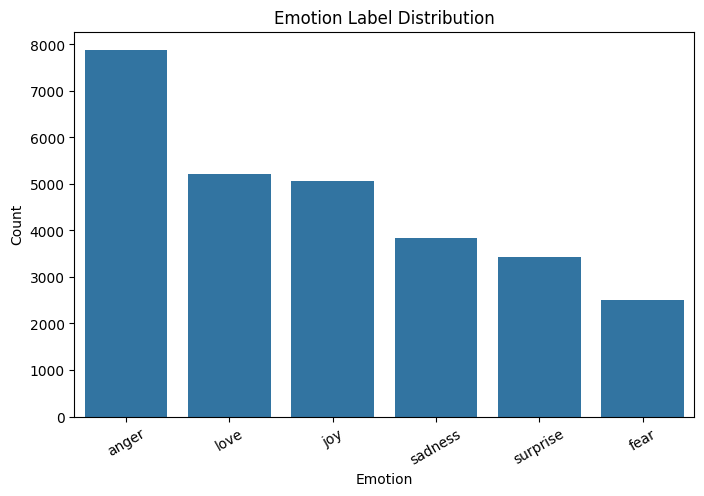

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="label", order=df["label"].value_counts().index)
plt.title("Emotion Label Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

In [15]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape[0])
print("Testing size:", X_test.shape[0])

Training size: 22328
Testing size: 5583


In [16]:
model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=15000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.9,
            stop_words="english"
        )
    ),
    (
        "classifier",
        LinearSVC(class_weight="balanced")
    )
])

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [17]:
model.fit(X_train, y_train)
print("Model training completed.")

Model training completed.


In [18]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7107289987461938

Classification Report:
              precision    recall  f1-score   support

       anger       0.77      0.74      0.76      1576
        fear       0.65      0.67      0.66       502
         joy       0.69      0.66      0.68      1012
        love       0.82      0.81      0.82      1042
     sadness       0.60      0.65      0.62       767
    surprise       0.63      0.64      0.63       684

    accuracy                           0.71      5583
   macro avg       0.69      0.70      0.69      5583
weighted avg       0.71      0.71      0.71      5583



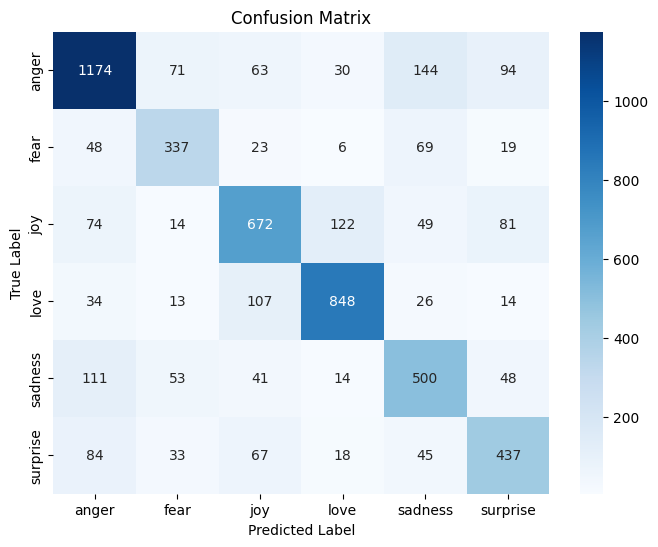

In [19]:
labels = model.classes_
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    cmap="Blues"
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [20]:
test_texts = [
    "Today was amazing. I completed my tasks and I feel happy and excited.",
    "I feel lonely and exhausted today. Nothing seems to be going right.",
    "I am really frustrated and angry about what happened.",
    "I am worried about my exams and scared about failing.",
    "I am grateful for the people who support me and make me feel loved.",
    "I received unexpected news today and I am still shocked.",
    "I am excited about applying for internships but also nervous about performing well."
]

predictions = model.predict(test_texts)

for text, emotion in zip(test_texts, predictions):
    print(f"Text: {text}")
    print(f"Predicted Emotion: {emotion}")
    print("-" * 80)

Text: Today was amazing. I completed my tasks and I feel happy and excited.
Predicted Emotion: joy
--------------------------------------------------------------------------------
Text: I feel lonely and exhausted today. Nothing seems to be going right.
Predicted Emotion: sadness
--------------------------------------------------------------------------------
Text: I am really frustrated and angry about what happened.
Predicted Emotion: anger
--------------------------------------------------------------------------------
Text: I am worried about my exams and scared about failing.
Predicted Emotion: fear
--------------------------------------------------------------------------------
Text: I am grateful for the people who support me and make me feel loved.
Predicted Emotion: love
--------------------------------------------------------------------------------
Text: I received unexpected news today and I am still shocked.
Predicted Emotion: surprise
-------------------------------------

In [21]:
def predict_emotion(text):
    cleaned = clean_text(text)
    prediction = model.predict([cleaned])[0]
    return prediction

example = "I feel stressed and overwhelmed with my workload."
print(predict_emotion(example))

sadness


In [25]:
os.makedirs("models", exist_ok=True)

MODEL_PATH = "../models/emotion_model.pkl"
joblib.dump(model, MODEL_PATH)

print(f"Model saved to: {MODEL_PATH}")

Model saved to: ../models/emotion_model.pkl


In [28]:
loaded_model = joblib.load("../models/emotion_model.pkl")

text = ["I feel very sad and tired today."]
prediction = loaded_model.predict(text)[0]

print("Prediction from loaded model:", prediction)

Prediction from loaded model: sadness


In [29]:
requirements = """pandas
numpy
scikit-learn
matplotlib
seaborn
joblib
"""

with open("requirements.txt", "w") as file:
    file.write(requirements)

print("requirements.txt saved.")

requirements.txt saved.
